In [1]:
import sys
sys.path.append('/home/caoren/tmp/PIRC_for_HigherOrderCausality')
import os
os.chdir("/home/caoren/tmp/PIRC_for_HigherOrderCausality/Lorenz")
import numpy as np
from Data_gen import *
from Torch_Library import *
from Model.PIRC import PIRC_flatten as Nonliear_PIRC
from sklearn.preprocessing import normalize
from functools import partial
node_num=3
N_train=2000
N_test=100
N_washout=100
N_start=0
dt=0.001
use_sin=0
device = torch.device("cuda:3")

ExpandNodes = node_num + math.comb(node_num - 1, 2)
set_seed(42)
t_all=(N_train+N_test+N_washout+N_start+1)*dt

# data generation
t, xyz = generate_lorenz_data(
    t_span=(0, t_all),
    dt=dt,
    initial_state=(1.0, 1.0, 1.0),
    sigma=10.0,
    rho=28.0,
    beta=8 / 3
)
X = xyz.T  # (N, 3)
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)  # normalization
data=X

#ground Truth matrix
T_Matrix=[
    [1,1,0,0],
    [1,1,0,1],
    [0,0,1,1]
]
ExpandNodes = (node_num + math.comb(node_num - 1, 2)+1)
n_units=5
alpha=0.1
sigma_in=0.4
rho=0.2
tikh=0.1
option=2
tau=2
method='Logistic'
connectivity=1.0
I_type=1
mode=2
block_dim=1
Base='prediction'
set_seed(42)

Win, Wres = Random_Win_Fixed_Wres(
        ExpandNodes, n_units, device,
        block_dim=block_dim, connectivity=connectivity
    )
X = torch.as_tensor(data, dtype=torch.float32, device=device)
X_batch = torch.stack(
    [shift_column_to_first(X, i) for i in range(node_num)],
    dim=0
)
X_washout, X_train, Y_train, Y_test = split_dataset2_batch(
    X_batch,
    N_washout,
    N_train,
    N_test,
    in_dim=node_num,
    out_dim=node_num
)

T_tensor = torch.as_tensor(T_Matrix, dtype=torch.float32, device=device)

pirc = Nonliear_PIRC(
        n_units=n_units, in_dim=node_num, out_dim=node_num,
        Win=Win, Wres=Wres,
        sigma_in=sigma_in, rho=rho, alpha=alpha, tikh=tikh, mode=mode, bias=0, dt=dt,
        device=device, block_dim=block_dim, I_type=I_type, option=option
    )

R, _ = pirc.train(X_washout, X_train, Y_train)
Y_test_predict = pirc.Prediction2(R, N_test, Y_train, Y_test)

base_all = Y_test_predict[0, :, :N_test, 0]  # base: (B, T)
others_all = Y_test_predict[2: , :, :N_test, 0]  # others: (E, B, T)
total_mse =  ((Y_test[0,:,:].T-base_all).pow(2).sum())/(base_all.shape[0]*base_all.shape[1])
base_expand = base_all.unsqueeze(0).expand_as(others_all)  # (E, B, T)
score_EN = score_0_1_torch(
    others_all,
    base_expand,
    method=method,
    tau=tau
)
Score = score_EN.transpose(0, 1).contiguous()  # (B, E)
print(score_EN)
print(f"Score:{Score}")

Score = shift_column_for_Causal_Matrix(Score)
print(f"Shif_Score:{Score}, \nT_tensor:{T_tensor}")

Score.fill_diagonal_(1.0)
AUC = ranking_auc_ALL(Score, T_tensor)
Loss=1-AUC+total_mse
print(f"AUC: { AUC}, MSE: {total_mse}, Loss:{Loss}")

/home/caoren/anaconda3/envs/pytorch/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tensor([[1.0966e-03, 1.3967e-03, 1.1746e-05],
        [1.3239e-03, 1.4373e-03, 2.9583e-04],
        [6.0506e-07, 2.2249e-05, 2.1894e-04],
        [2.0930e-05, 1.4032e-03, 5.5196e-04]], device='cuda:3')
Score:tensor([[1.0966e-03, 1.3239e-03, 6.0506e-07, 2.0930e-05],
        [1.3967e-03, 1.4373e-03, 2.2249e-05, 1.4032e-03],
        [1.1746e-05, 2.9583e-04, 2.1894e-04, 5.5196e-04]], device='cuda:3')
Shif_Score:tensor([[1.0966e-03, 1.3239e-03, 6.0506e-07, 2.0930e-05],
        [1.4373e-03, 1.3967e-03, 2.2249e-05, 1.4032e-03],
        [2.9583e-04, 2.1894e-04, 1.1746e-05, 5.5196e-04]], device='cuda:3'), 
T_tensor:tensor([[1., 1., 0., 0.],
        [1., 1., 0., 1.],
        [0., 0., 1., 1.]], device='cuda:3')
AUC: 1.0, MSE: 8.39164556509786e-07, Loss:8.39164556509786e-07


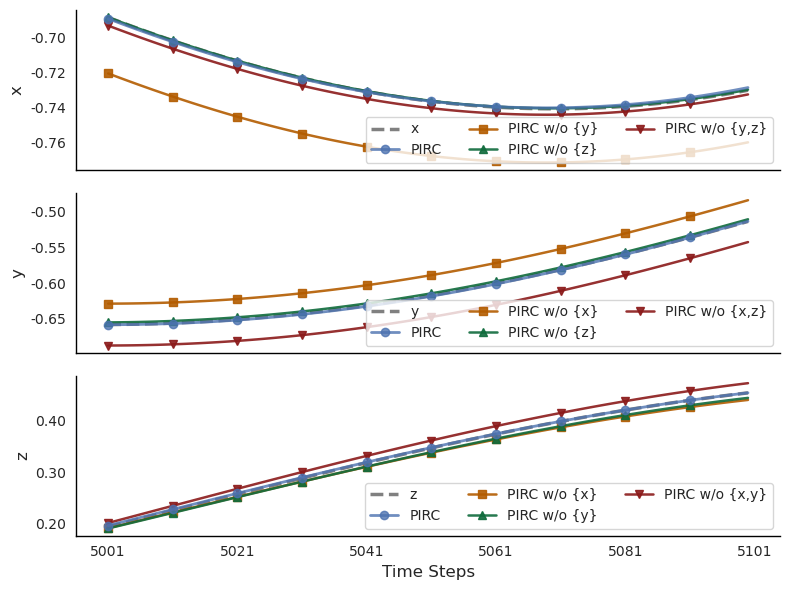

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

variable_num, time_steps = Y_test_predict[0, :, :N_test, 0].shape

variable_list = ['x', 'y', 'z']

intervention_dict = {
    'x': ["PIRC w/o {y}", "PIRC w/o {z}", "PIRC w/o {y,z}"],
    'y': ["PIRC w/o {x}", "PIRC w/o {z}", "PIRC w/o {x,z}"],
    'z': ["PIRC w/o {x}", "PIRC w/o {y}", "PIRC w/o {x,y}"]
}

t = np.arange(time_steps)

colors = [
    '#0b3c5d',  # 深蓝
    '#b35c00',  # 深橙
    '#0f6b3c',  # 深绿
    '#8b1a1a',  # 深红
    '#4b3f72',  # 深紫
    '#5a3e36',  # 深棕
    '#7a2e5c',  # 深粉紫
    '#3a3a3a',  # 深灰
    '#6b6b00',  # 橄榄深黄
    '#0e5f5f'   # 深青
]
markers = [
    'o','s','^','v','<','>','D','d','p','h','H','*','X','P'
]

# ======================
# 子图（关键）
# ======================
fig, axes = plt.subplots(variable_num, 1, figsize=(8, 6))

if variable_num == 1:
    axes = [axes]

# ======================
# 主循环
# ======================
for variable_id in range(variable_num):

    ax = axes[variable_id]
    var_name = variable_list[variable_id]

    # ===== 数据（完全保留你的写法）=====
    gt = Y_test[0, :, variable_id].detach().cpu().numpy()

    base = Y_test_predict[0, :, :N_test, 0].detach().cpu().numpy()
    base = base[variable_id, :]

    # ===== Ground Truth =====
    ax.plot(
        t, gt,
        linestyle='--',
        color='gray',
        linewidth=2.5,
        label=var_name
        # label='Ground Truth'
    )

    # ===== Baseline =====
    ax.plot(
        t, base,
        color='#4C72B0',
        marker=markers[0],
        markevery=10,
        linewidth=2,
        alpha=0.8,
        label='PIRC',
        zorder=4
    )

    # ===== 干预 =====
    for idx, label in enumerate(intervention_dict[var_name]):

        inter = Y_test_predict[3 + idx, :, :N_test, 0].detach().cpu().numpy()
        inter = inter[variable_id, :]

        ax.plot(
            t, inter,
            color=colors[idx+1],
            marker=markers[idx+1],
            markevery=10,
            linewidth=1.8,
            alpha=0.9,
            label=label
        )

        ax.grid(False)

    # # ===== Ground Truth =====
    # ax.plot(
    #     t, gt,
    #     linestyle='--',
    #     color='gray',
    #     linewidth=3,
    #     label=var_name
    #     # label='Ground Truth'
    # )

    # ===== 只最后一张图显示 legend =====
    # if variable_id == variable_num - 1:
    ax.legend(
        loc='lower right',
        # frameon=False,
        fontsize=10,
        ncol=3
    )

    # ===== 标签 =====
    ax.set_ylabel(var_name, fontsize=12)
    if variable_id == variable_num - 1:
        ax.set_xlabel("Time Steps", fontsize=12)
    else:
        ax.set_xlabel("")
        # ax.set_xticks(t)
    if variable_id == variable_num - 1:
        # ax.set_xticks(t)
        from matplotlib.ticker import FuncFormatter
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x + 5001)}"))
        # ax.tick_params(axis='x', labelsize=10)
    else:
        ax.set_xticks([])  # 或者 ax.set_xticklabels([])
        # ax.set_xticks(t)
        # ax.tick_params(axis='x', labelsize=10)
    # ===== 美化 =====
    # ax.grid(alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for spine in ['left', 'bottom']:
            ax.spines[spine].set_color('black')
            ax.spines[spine].set_linewidth(1)
    from matplotlib.ticker import FormatStrFormatter
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# ======================
# 紧凑布局
# ======================
# plt.subplots_adjust(hspace=0.5)

plt.tight_layout()
plt.savefig(
    "pirc_timeseries.png",   # 文件名（推荐 PDF/EPS 用于论文）
    dpi=1200,                # 分辨率
    bbox_inches='tight'     # 去掉多余白边
)

plt.show()

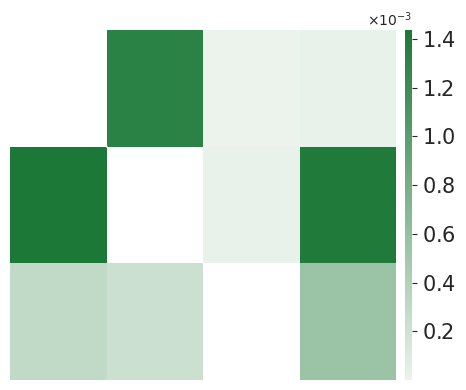

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

score_np = Score.detach().cpu().numpy()
B, E = score_np.shape

mask = np.eye(B, E, dtype=bool)

plt.figure(figsize=(5, 4))

ax = sns.heatmap(
    score_np,
    mask=mask,
    cmap = sns.light_palette("#1b7837", as_cmap=True),
    cbar=True,
    cbar_kws={
        "shrink": 1.0,
        "aspect": 50,   # 👈 控制细长程度（越大越细长）
        "pad": 0.02     # 👈 和图的间距
    },
    linewidths=0,        # ❌ 关网格
    xticklabels=False,   # ❌ 关 xtick
    yticklabels=False    # ❌ 关 ytick
)

# === 拿到 colorbar ===
cbar = ax.collections[0].colorbar

# === 1️⃣ 科学计数法 ===
import matplotlib.ticker as ticker
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2))   # 超过这个范围才用科学计数法
cbar.ax.yaxis.set_major_formatter(formatter)

# === 2️⃣ 字体大小 ===
cbar.ax.tick_params(labelsize=15)

# === 3️⃣ 指数 (×10^x) 字体大小 ===
cbar.ax.yaxis.get_offset_text().set_size(10)

# ❌ 再保险：彻底关 ticks
ax.set_xticks([])
ax.set_yticks([])

# ❌ 去掉边框（更干净）
# for spine in ax.spines.values():
#     spine.set_visible(False)

# === 虚线对角线 ===
n = min(B, E)
ax.plot(
    np.arange(n) + 0.5,
    np.arange(n) + 0.5,
    linestyle='--',
    color='white',
    linewidth=1.2
)

plt.tight_layout()
plt.savefig(
    "Lorenz_heatmap_Green.png",
    dpi=1200,
    bbox_inches='tight',
    pad_inches=0.02
)
plt.show()